# MO-IT148 — Week 7: Line Plot of IoT Sensor Readings Over Time
**H3101 Group ADET**

This notebook loads the cleaned IoT logistics data from Week 6 (`cleaned_iot_data.csv`) and visualizes temperature sensor readings over time, with each delivery **status** (In Transit / Delayed / Delivered) shown in a different color.

> **Prerequisite:** `cleaned_iot_data.csv` (from Week 6) must be in the same folder as this notebook.

## Step 1 — Load the Cleaned IoT Data

In [1]:
import pandas as pd

# Load cleaned IoT data (output of Week 6)
df = pd.read_csv("cleaned_iot_data.csv")

# Display first few rows to verify data
print("Data loaded. Shape:", df.shape)
df.head()


Data loaded. Shape: (100, 9)


,device_id,data_type,data_value,package_id,location,temperature,status,timestamp,numeric_value
0,RFID_0,Logistics,"PKG:1064 | LOC:12.422315329212937,121.19571255...",1064,"12.422315329212937,121.19571255545216",3.824191,In Transit,2026-01-01 00:00:00,3.824191
1,RFID_1,Logistics,"PKG:1060 | LOC:13.513377156951517,122.51412936...",1060,"13.513377156951517,122.51412936901205",2.927017,In Transit,2026-01-01 01:00:00,2.927017
2,RFID_2,Logistics,"PKG:1015 | LOC:14.291035309309276,122.54491741...",1015,"14.291035309309276,122.54491741023237",5.466066,In Transit,2026-01-01 02:00:00,5.466066
3,RFID_3,Logistics,"PKG:1050 | LOC:10.539635016080613,123.66811295...",1050,"10.539635016080613,123.66811295673534",4.441660,Delayed,2026-01-01 03:00:00,4.441660
4,RFID_4,Logistics,"PKG:1048 | LOC:10.465063725075503,122.47830568...",1048,"10.465063725075503,122.47830568516888",2.582283,In Transit,2026-01-01 04:00:00,2.582283


## Step 2 — Convert Timestamp to Datetime

In [2]:
# Convert timestamp column to datetime for proper time-axis plotting
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Sort by time so the lines connect in chronological order
df = df.sort_values("timestamp")

print("Timestamp dtype:", df["timestamp"].dtype)
print("Time range:", df["timestamp"].min(), "to", df["timestamp"].max())


Timestamp dtype: datetime64[us]
Time range: 2026-01-01 00:00:00 to 2026-01-05 03:00:00


## Step 3 — Import Visualization Libraries & Set Style

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visualization style
sns.set(style="whitegrid")
print("Libraries imported and style set.")


Libraries imported and style set.


## Step 4 — Create the Line Plot

We plot **temperature** (`numeric_value`) over time, coloring each line by **status**.
Since our logistics dataset has a single `data_type` ("Logistics"), we use `status`
as the category (hue) so the graph shows different colors per delivery condition —
satisfying the requirement of "each sensor type in a different color.

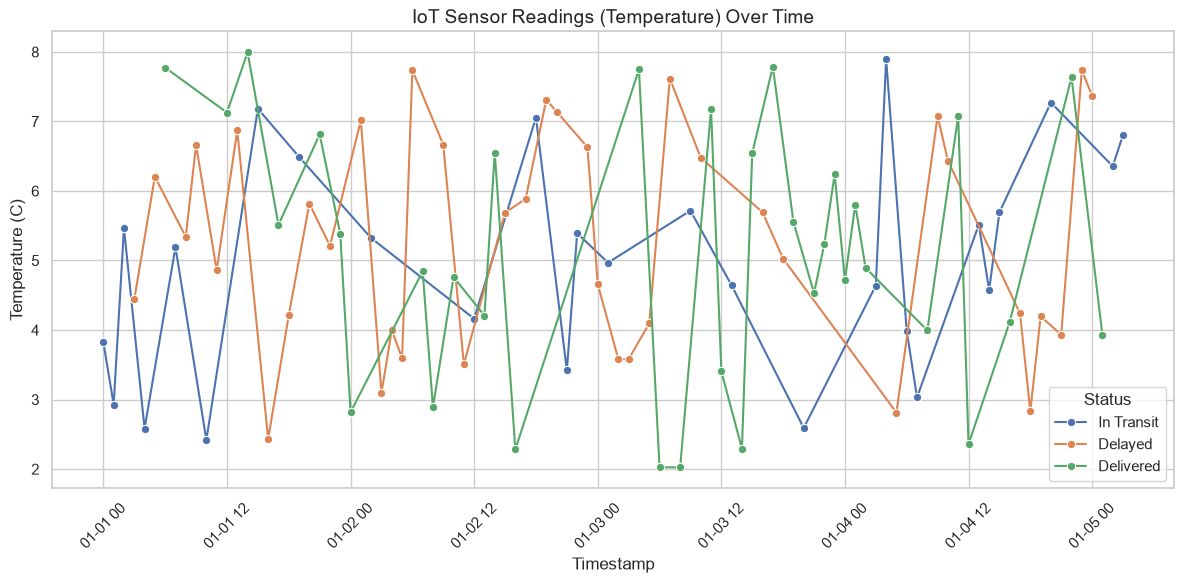

In [4]:
plt.figure(figsize=(12, 6))   # Adjust figure size

# Line plot: temperature over time, one colored line per status
sns.lineplot(
    x=df["timestamp"],
    y=df["numeric_value"],
    hue=df["status"],
    marker="o"
)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add title and labels
plt.title("IoT Sensor Readings (Temperature) Over Time", fontsize=14)
plt.xlabel("Timestamp", fontsize=12)
plt.ylabel("Temperature (C)", fontsize=12)

# Show legend
plt.legend(title="Status")

plt.tight_layout()
plt.show()


## Step 5 — Save the Plot as an Image (for submission)

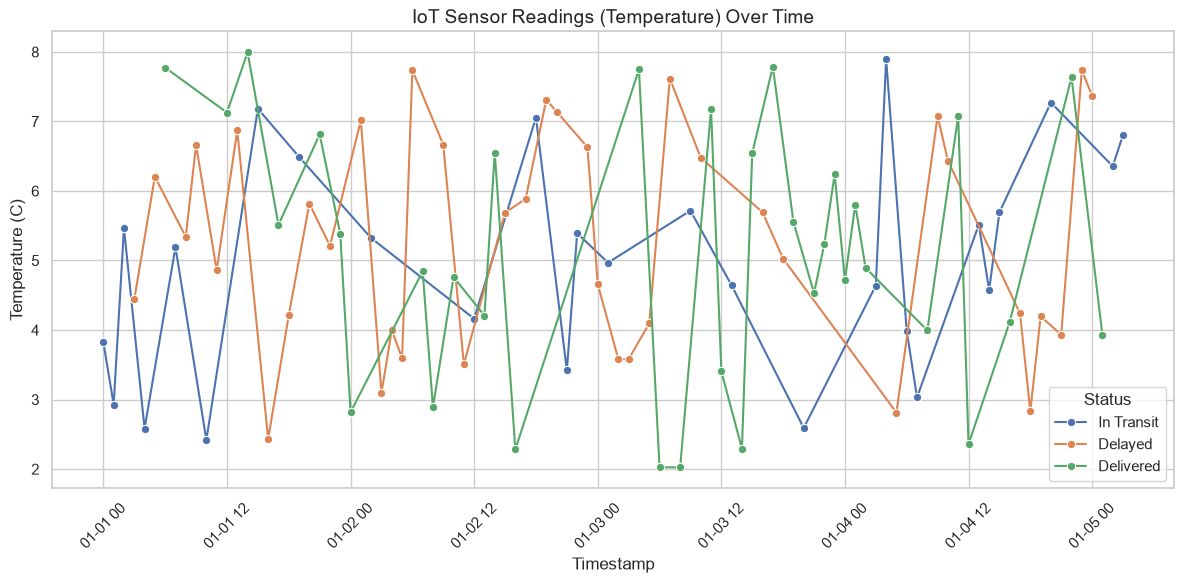

Plot saved as iot_sensor_lineplot.png


In [5]:
# Re-create and save the figure to a PNG file for your documentation / GitHub
plt.figure(figsize=(12, 6))
sns.lineplot(
    x=df["timestamp"],
    y=df["numeric_value"],
    hue=df["status"],
    marker="o"
)
plt.xticks(rotation=45)
plt.title("IoT Sensor Readings (Temperature) Over Time", fontsize=14)
plt.xlabel("Timestamp", fontsize=12)
plt.ylabel("Temperature (C)", fontsize=12)
plt.legend(title="Status")
plt.tight_layout()
plt.savefig("iot_sensor_lineplot.png", dpi=150)
plt.show()

print("Plot saved as iot_sensor_lineplot.png")


## Step 6 — Insights from the Time-Series Data

Use the cell below to compute simple insights you can discuss in the synchronous session.

In [6]:
# Average temperature per status
print("Average temperature by status:")
print(df.groupby("status")["numeric_value"].mean().round(2))
print()

# Overall stats
print(f"Overall temperature — min: {df['numeric_value'].min():.2f}C, "
      f"max: {df['numeric_value'].max():.2f}C, "
      f"mean: {df['numeric_value'].mean():.2f}C")
print()

# Count of records per status
print("Number of readings per status:")
print(df["status"].value_counts())


Average temperature by status:
status
Delayed       5.32
Delivered     5.12
In Transit    5.00
Name: numeric_value, dtype: float64

Overall temperature — min: 2.02C, max: 8.00C, mean: 5.17C

Number of readings per status:
status
Delayed       39
Delivered     34
In Transit    27
Name: count, dtype: int64
